# BGGTDM v2 — Data Fetch + Feature Exploration

**Goal:** Build the full training dataset from scratch using Tank01 box scores.

**Approach:**
1. Build a player→position lookup from all 32 current rosters
2. For each season (2022–2025), fetch schedule → box scores → extract game logs
3. Filter to WR + TE only
4. Save to `data/game_logs_raw.csv`
5. Explore features, brainstorm v2 feature set

**API budget estimate:** ~32 roster calls + ~1,150 box score calls = ~1,200 total
With 0.5s delay between calls: ~10 minutes total. Progress is saved after each season so you can resume.

In [2]:
import pandas as pd
import numpy as np
import requests
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

API_KEY = 'REDACTED'
BASE_URL = 'https://tank01-nfl-live-in-game-real-time-statistics-nfl.p.rapidapi.com'
HEADERS = {
    'X-RapidAPI-Key': API_KEY,
    'X-RapidAPI-Host': 'tank01-nfl-live-in-game-real-time-statistics-nfl.p.rapidapi.com'
}

NFL_TEAMS = [
    'ARI', 'ATL', 'BAL', 'BUF', 'CAR', 'CHI', 'CIN', 'CLE',
    'DAL', 'DEN', 'DET', 'GB',  'HOU', 'IND', 'JAX', 'KC',
    'LAC', 'LAR', 'LV',  'MIA', 'MIN', 'NE',  'NO',  'NYG',
    'NYJ', 'PHI', 'PIT', 'SF',  'SEA', 'TB',  'TEN', 'WSH'
]

def api_get(endpoint, params, delay=0.4):
    """Make a Tank01 API call with rate limiting."""
    url = f'{BASE_URL}/{endpoint}'
    r = requests.get(url, headers=HEADERS, params=params, timeout=30)
    r.raise_for_status()
    time.sleep(delay)
    data = r.json()
    return data.get('body', data)

print('Ready')

Ready


---
## Step 1 — Build Player→Position Lookup

Fetch all 32 team rosters to get `playerID → {pos, longName, exp, draftRd}` mapping.
We use this to filter box scores to WR/TE only and attach player metadata.

Note: `draftRd` is in the `wrGameLog.csv` but NOT in the roster API. We'll grab it from the existing CSV.

In [3]:
player_lookup_path = DATA_DIR / 'player_lookup.json'

if player_lookup_path.exists():
    with open(player_lookup_path) as f:
        player_lookup = json.load(f)
    print(f'Loaded existing player lookup: {len(player_lookup)} players')
else:
    player_lookup = {}
    print('Fetching all 32 team rosters...')

    for team in NFL_TEAMS:
        try:
            body = api_get('getNFLTeamRoster', {'teamAbv': team, 'getStats': 'false'})
            roster = body.get('roster', [])
            for p in roster:
                pid = p.get('playerID') or p.get('espnID')
                if pid:
                    player_lookup[str(pid)] = {
                        'name': p.get('longName') or p.get('espnName', ''),
                        'pos': p.get('pos', ''),
                        'team': p.get('team', team),
                        'exp': p.get('exp', ''),
                    }
            print(f'  {team}: {len(roster)} players')
        except Exception as e:
            print(f'  {team}: ERROR — {e}')

    with open(player_lookup_path, 'w') as f:
        json.dump(player_lookup, f)
    print(f'\nSaved {len(player_lookup)} players to player_lookup.json')

# Count WR/TE
wr_count = sum(1 for p in player_lookup.values() if p['pos'] == 'WR')
te_count = sum(1 for p in player_lookup.values() if p['pos'] == 'TE')
print(f'WR: {wr_count}, TE: {te_count}')

Fetching all 32 team rosters...
  ARI: 78 players
  ATL: 74 players
  BAL: 69 players
  BUF: 79 players
  CAR: 71 players
  CHI: 70 players
  CIN: 73 players
  CLE: 72 players
  DAL: 71 players
  DEN: 73 players
  DET: 74 players
  GB: 81 players
  HOU: 69 players
  IND: 81 players
  JAX: 73 players
  KC: 76 players
  LAC: 71 players
  LAR: 68 players
  LV: 72 players
  MIA: 78 players
  MIN: 69 players
  NE: 74 players
  NO: 74 players
  NYG: 81 players
  NYJ: 80 players
  PHI: 71 players
  PIT: 81 players
  SF: 80 players
  SEA: 73 players
  TB: 71 players
  TEN: 71 players
  WSH: 73 players

Saved 2371 players to player_lookup.json
WR: 298, TE: 126


In [4]:
# Pull draft round from existing wrGameLog.csv (not in roster API)
# We'll use this to enrich the player lookup
wr_df = pd.read_csv(DATA_DIR / 'wrGameLog.csv')
draft_rd_map = (
    wr_df[['fullName', 'draftRd']]
    .dropna(subset=['fullName'])
    .drop_duplicates('fullName')
    .set_index('fullName')['draftRd']
    .to_dict()
)
print(f'Draft round data for {len(draft_rd_map)} players from existing CSV')
print('Sample:', list(draft_rd_map.items())[:5])

Draft round data for 219 players from existing CSV
Sample: [('Greg Dortch', nan), ('Zay Jones', 2.0), ('Chris Moore', 4.0), ('Zach Pascal', nan), ('KhaDarel Hodge', nan)]


---
## Step 2 — Fetch Game Logs via Box Scores

For each season and week:
1. `getNFLGamesForWeek` → get game IDs
2. `getNFLBoxScore` per game → extract all receiving stats
3. Filter to WR/TE using player_lookup

Progress saves after each season so you can stop and resume.

In [5]:
def get_game_ids_for_week(season, week):
    """Get all game IDs for a given season/week."""
    body = api_get('getNFLGamesForWeek', {
        'season': str(season),
        'week': str(week),
        'seasonType': 'reg'
    })
    if isinstance(body, list):
        return [g.get('gameID') for g in body if g.get('gameID')]
    return []

def extract_receiving_logs_from_box_score(game_id, season, week, player_lookup):
    """Fetch box score and extract WR/TE receiving logs."""
    body = api_get('getNFLBoxScore', {'gameID': game_id, 'playByPlay': 'false'})
    player_stats = body.get('playerStats', {})
    logs = []

    for pid, stats in player_stats.items():
        rec = stats.get('Receiving')
        if not rec:
            continue

        # Check position — only WR/TE
        meta = player_lookup.get(str(pid), {})
        pos = meta.get('pos', '')
        if pos not in ('WR', 'TE'):
            continue

        try:
            logs.append({
                'player_id': str(pid),
                'name': meta.get('name', stats.get('longName', '')),
                'pos': pos,
                'team': stats.get('team', ''),
                'game_id': game_id,
                'season': season,
                'week': week,
                'receptions': int(rec.get('receptions', 0) or 0),
                'targets': int(rec.get('targets', 0) or 0),
                'rec_yards': int(rec.get('recYds', 0) or 0),
                'rec_tds': int(rec.get('recTD', 0) or 0),
                'long_rec': int(rec.get('longRec', 0) or 0),
                'rec_avg': float(rec.get('recAvg', 0) or 0),
            })
        except (ValueError, TypeError):
            continue

    return logs

print('Functions defined')

Functions defined


In [6]:
# Test with one game before running the full fetch
# Use a known 2024 week 1 game
test_game_ids = get_game_ids_for_week(2024, 1)
print(f'Week 1 2024 game IDs ({len(test_game_ids)}):')
print(test_game_ids[:5])

Week 1 2024 game IDs (16):
['20240905_BAL@KC', '20240906_GB@PHI', '20240908_ARI@BUF', '20240908_CAR@NO', '20240908_DAL@CLE']


In [7]:
# Test one box score
test_logs = extract_receiving_logs_from_box_score(test_game_ids[0], 2024, 1, player_lookup)
print(f'Players with receiving stats in {test_game_ids[0]}: {len(test_logs)}')
pd.DataFrame(test_logs)

Players with receiving stats in 20240905_BAL@KC: 10


,player_id,name,pos,team,game_id,season,week,receptions,targets,rec_yards,rec_tds,long_rec,rec_avg
0,3116365,Mark Andrews,TE,BAL,20240905_BAL@KC,2024,1,2,2,14,0,11,7.000
1,3120348,JuJu Smith-Schuster,WR,KC,20240905_BAL@KC,2024,1,0,1,0,0,0,0.000
2,4428331,Rashee Rice,WR,KC,20240905_BAL@KC,2024,1,7,9,103,0,33,14.700
3,4360939,Rashod Bateman,WR,BAL,20240905_BAL@KC,2024,1,2,5,53,0,38,26.500
4,4361050,Isaiah Likely,TE,BAL,20240905_BAL@KC,2024,1,9,12,111,1,49,12.300
5,4683062,Xavier Worthy,WR,KC,20240905_BAL@KC,2024,1,2,3,47,1,35,23.500
6,4240472,Noah Gray,TE,KC,20240905_BAL@KC,2024,1,3,3,37,0,13,12.300
7,15847,Travis Kelce,TE,KC,20240905_BAL@KC,2024,1,3,4,34,0,23,11.300
8,3118892,Justin Watson,WR,KC,20240905_BAL@KC,2024,1,1,1,25,0,25,25.000
9,4429615,Zay Flowers,WR,BAL,20240905_BAL@KC,2024,1,6,10,37,0,19,6.200


In [8]:
# ============================================================
# FULL FETCH — runs for ~10 minutes, saves per-season CSVs
# Set SEASONS to skip any already-fetched seasons
# ============================================================
SEASONS = [2022, 2023, 2024, 2025]   # Edit to skip already-done seasons
WEEKS = range(1, 19)                  # Weeks 1-18

for season in SEASONS:
    out_path = DATA_DIR / f'game_logs_{season}.csv'
    if out_path.exists():
        print(f'{season}: already exists, skipping. Delete file to re-fetch.')
        continue

    season_logs = []
    print(f'\n=== Fetching {season} ===')

    for week in WEEKS:
        try:
            game_ids = get_game_ids_for_week(season, week)
            if not game_ids:
                print(f'  Week {week}: no games')
                continue

            week_logs = []
            for gid in game_ids:
                try:
                    logs = extract_receiving_logs_from_box_score(gid, season, week, player_lookup)
                    week_logs.extend(logs)
                except Exception as e:
                    print(f'  Week {week} game {gid}: ERROR — {e}')

            season_logs.extend(week_logs)
            print(f'  Week {week}: {len(game_ids)} games, {len(week_logs)} WR/TE logs')

        except Exception as e:
            print(f'  Week {week}: SCHEDULE ERROR — {e}')

    if season_logs:
        df_season = pd.DataFrame(season_logs)
        df_season.to_csv(out_path, index=False)
        print(f'  Saved {len(df_season)} rows to {out_path.name}')
    else:
        print(f'  No data for {season}')

print('\nDone!')


=== Fetching 2022 ===
  Week 1: 16 games, 109 WR/TE logs
  Week 2: 16 games, 104 WR/TE logs
  Week 3: 16 games, 109 WR/TE logs
  Week 4: 16 games, 115 WR/TE logs
  Week 5: 16 games, 114 WR/TE logs
  Week 6: 14 games, 98 WR/TE logs
  Week 7: 14 games, 102 WR/TE logs
  Week 8: 15 games, 100 WR/TE logs
  Week 9: 13 games, 99 WR/TE logs
  Week 10: 14 games, 98 WR/TE logs
  Week 11: 14 games, 98 WR/TE logs
  Week 12: 16 games, 105 WR/TE logs
  Week 13: 15 games, 114 WR/TE logs
  Week 14: 13 games, 91 WR/TE logs
  Week 15: 16 games, 114 WR/TE logs
  Week 16: 16 games, 108 WR/TE logs
  Week 17: 16 games, 106 WR/TE logs
  Week 18: 16 games, 110 WR/TE logs
  Saved 1894 rows to game_logs_2022.csv

=== Fetching 2023 ===
  Week 1: 16 games, 132 WR/TE logs
  Week 2: 16 games, 134 WR/TE logs
  Week 3: 16 games, 139 WR/TE logs
  Week 4: 16 games, 140 WR/TE logs
  Week 5: 14 games, 125 WR/TE logs
  Week 6: 15 games, 125 WR/TE logs
  Week 7: 13 games, 109 WR/TE logs
  Week 8: 16 games, 132 WR/TE logs


---
## Step 3 — Combine & Inspect

In [9]:
# Load all season CSVs and combine
dfs = []
for season in [2022, 2023, 2024, 2025]:
    p = DATA_DIR / f'game_logs_{season}.csv'
    if p.exists():
        d = pd.read_csv(p)
        dfs.append(d)
        print(f'{season}: {len(d)} rows, {d["player_id"].nunique()} players')
    else:
        print(f'{season}: not fetched yet')

df = pd.concat(dfs, ignore_index=True)
df['scored_td'] = (df['rec_tds'] > 0).astype(int)
print(f'\nTotal: {len(df)} rows, {df["player_id"].nunique()} unique players')
df.head()

2022: 1894 rows, 171 players
2023: 2364 rows, 215 players
2024: 2688 rows, 263 players
2025: 3026 rows, 317 players

Total: 9972 rows, 353 unique players


,player_id,name,pos,team,game_id,season,week,receptions,targets,rec_yards,rec_tds,long_rec,rec_avg,scored_td
0,3930086,Dawson Knox,TE,BUF,20220908_BUF@LAR,2022,1,1,2,5,0,5,5.000,0
1,4360797,Tutu Atwell,WR,LAR,20220908_BUF@LAR,2022,1,0,1,0,0,0,0.000,0
2,4035656,Ben Skowronek,WR,LAR,20220908_BUF@LAR,2022,1,4,6,25,0,12,6.300,0
3,4243537,Gabe Davis,WR,BUF,20220908_BUF@LAR,2022,1,4,5,88,1,47,22.000,1
4,2573401,Tyler Higbee,TE,LAR,20220908_BUF@LAR,2022,1,5,11,39,0,11,7.800,0


In [10]:
# Key dataset stats
print('Season distribution:')
print(df.groupby(['season', 'pos']).size().unstack(fill_value=0))
print()
print('Overall TD rate:')
print(df.groupby('pos')['scored_td'].mean().round(3))
print()
print('TD rate by season + pos:')
print(df.groupby(['season', 'pos'])['scored_td'].mean().round(3).unstack())

Season distribution:
pos       TE    WR
season            
2022     711  1183
2023     815  1549
2024     911  1777
2025    1035  1991

Overall TD rate:
pos
TE   0.166
WR   0.218
Name: scored_td, dtype: float64

TD rate by season + pos:
pos       TE    WR
season            
2022   0.173 0.215
2023   0.150 0.223
2024   0.151 0.233
2025   0.187 0.202


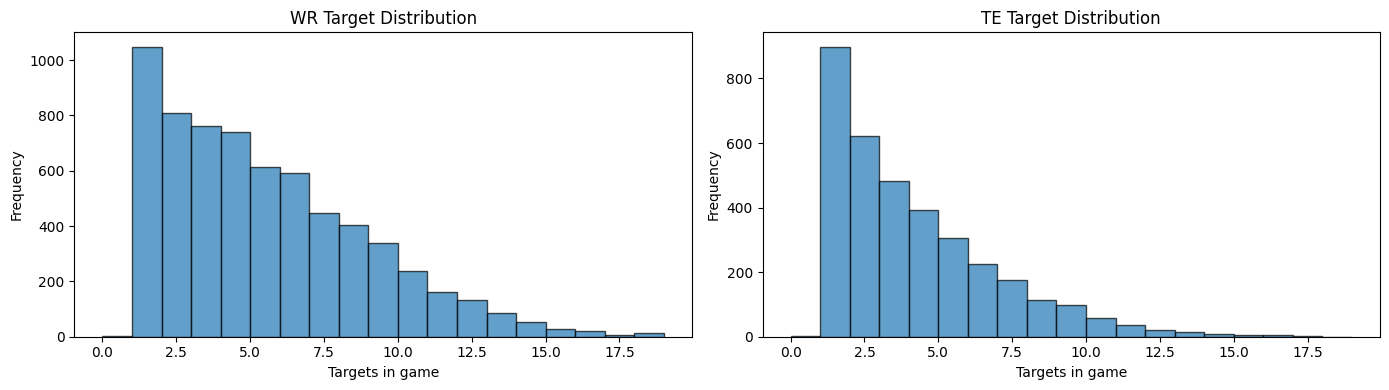

Target stats by position:
       count  mean   std   min   25%   50%   75%    max
pos                                                    
TE  3472.000 3.700 2.780 0.000 1.000 3.000 5.000 17.000
WR  6500.000 5.050 3.460 0.000 2.000 4.000 7.000 23.000


In [11]:
# Distribution of targets — key usage signal
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, pos in zip(axes, ['WR', 'TE']):
    sub = df[df['pos'] == pos]
    ax.hist(sub['targets'], bins=range(0, 20), alpha=0.7, edgecolor='black')
    ax.set_title(f'{pos} Target Distribution')
    ax.set_xlabel('Targets in game')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print('Target stats by position:')
print(df.groupby('pos')['targets'].describe().round(2))

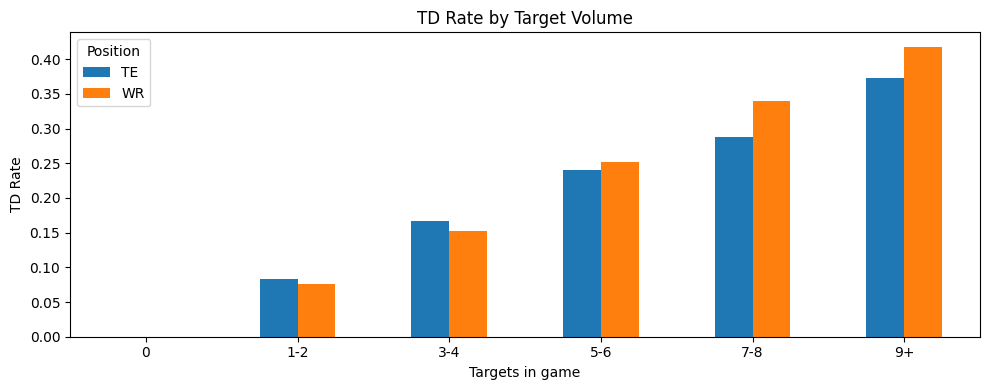

In [12]:
# TD rate by target count — how much does target volume predict TD?
df['target_bucket'] = pd.cut(df['targets'], bins=[-1, 0, 2, 4, 6, 8, 30], 
                              labels=['0', '1-2', '3-4', '5-6', '7-8', '9+'])

td_by_targets = df.groupby(['pos', 'target_bucket'])['scored_td'].mean().unstack(0)
td_by_targets.plot(kind='bar', figsize=(10, 4), title='TD Rate by Target Volume')
plt.ylabel('TD Rate')
plt.xlabel('Targets in game')
plt.xticks(rotation=0)
plt.legend(title='Position')
plt.tight_layout()
plt.show()

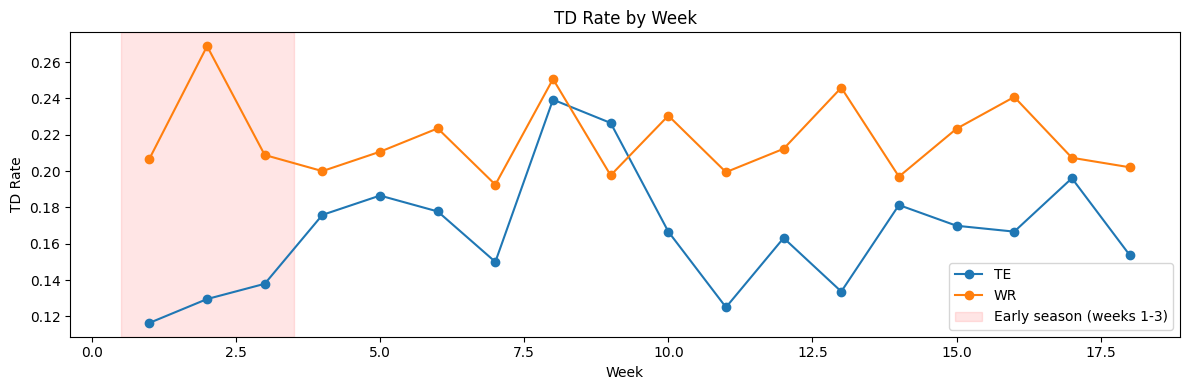

In [13]:
# TD rate by week — visualize early vs in-season
td_by_week = df.groupby(['week', 'pos'])['scored_td'].mean().unstack()
td_by_week.plot(figsize=(12, 4), marker='o', title='TD Rate by Week')
plt.axvspan(0.5, 3.5, alpha=0.1, color='red', label='Early season (weeks 1-3)')
plt.ylabel('TD Rate')
plt.xlabel('Week')
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 4 — Feature Engineering Exploration

Build the rolling features and check their predictive signal.
Two paths: **early season** (prior season stats) and **in-season** (rolling game logs).

In [14]:
def build_player_season_features(df):
    """
    For each game-week row, compute all features using only data
    available BEFORE that game (no leakage).
    
    Returns a DataFrame with feature columns added.
    """
    df = df.sort_values(['player_id', 'season', 'week']).reset_index(drop=True)

    grp = df.groupby(['player_id', 'season'])

    # ---- In-season rolling features (all shifted by 1 = lag) ----
    df['lag_yards']         = grp['rec_yards'].shift(1)
    df['lag_targets']       = grp['targets'].shift(1)
    df['lag_receptions']    = grp['receptions'].shift(1)

    # Cumulative (shifted) — season-to-date BEFORE this game
    df['cum_yards']         = grp['rec_yards'].cumsum().shift(1)
    df['cum_targets']       = grp['targets'].cumsum().shift(1)
    df['cum_receptions']    = grp['receptions'].cumsum().shift(1)
    df['cum_tds']           = grp['rec_tds'].cumsum().shift(1)
    df['games_played']      = grp.cumcount()  # 0-indexed (0 = first game of season)

    # Per-game averages (season-to-date)
    df['yards_pg']          = df['cum_yards'] / df['games_played'].clip(lower=1)
    df['targets_pg']        = df['cum_targets'] / df['games_played'].clip(lower=1)
    df['receptions_pg']     = df['cum_receptions'] / df['games_played'].clip(lower=1)

    # Rolling 3-game averages (shifted)
    for col, feat in [('rec_yards', 'roll3_yards'), ('targets', 'roll3_targets'), 
                       ('receptions', 'roll3_receptions')]:
        df[feat] = (
            grp[col]
            .transform(lambda x: x.rolling(3, min_periods=1).mean())
            .shift(1)
        )

    # TD rate per target (cumulative, shifted)
    df['td_rate_per_target'] = (df['cum_tds'] / df['cum_targets'].clip(lower=1))

    # Yards per reception (last game, shifted)
    df['lag_ypr'] = (df['lag_yards'] / df['lag_receptions'].clip(lower=1)).replace(np.inf, 0)

    # ---- New features ----

    # Target share trend: rolling3 targets vs season avg targets
    df['target_trend'] = df['roll3_targets'] / df['targets_pg'].clip(lower=0.1)

    # Weeks since last TD (within season)
    def weeks_since_td(series):
        result = []
        count = 0
        for val in series:
            result.append(count)
            if val > 0:
                count = 0
            else:
                count += 1
        return pd.Series(result, index=series.index)

    df['weeks_since_td'] = grp['rec_tds'].transform(weeks_since_td)

    # Position flag
    df['is_te'] = (df['pos'] == 'TE').astype(int)

    # Is this week 1 of the season (no prior game data)
    df['is_week1'] = (df['games_played'] == 0).astype(int)

    return df

df_feat = build_player_season_features(df.copy())
print(f'Features built: {df_feat.shape}')
df_feat.head(10)

Features built: (9972, 35)


,player_id,name,pos,team,game_id,season,week,receptions,targets,rec_yards,rec_tds,long_rec,rec_avg,scored_td,target_bucket,lag_yards,lag_targets,lag_receptions,cum_yards,cum_targets,cum_receptions,cum_tds,games_played,yards_pg,targets_pg,receptions_pg,roll3_yards,roll3_targets,roll3_receptions,td_rate_per_target,lag_ypr,target_trend,weeks_since_td,is_te,is_week1
0,15795,DeAndre Hopkins,WR,ARI,20221020_NO@ARI,2022,7,10,14,103,0,18,10.300,0,9+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1
1,15795,DeAndre Hopkins,WR,ARI,20221030_ARI@MIN,2022,8,12,13,159,1,33,13.300,1,9+,103.000,14.000,10.000,103.000,14.000,10.000,0.000,1,103.000,14.000,10.000,103.000,14.000,10.000,0.000,10.300,1.000,1,0,0
2,15795,DeAndre Hopkins,WR,ARI,20221106_SEA@ARI,2022,9,4,5,36,1,22,9.000,1,5-6,159.000,13.000,12.000,262.000,27.000,22.000,1.000,2,131.000,13.500,11.000,131.000,13.500,11.000,0.037,13.250,1.000,0,0,0
3,15795,DeAndre Hopkins,WR,ARI,20221113_ARI@LAR,2022,10,10,14,98,0,25,9.800,0,9+,36.000,5.000,4.000,298.000,32.000,26.000,2.000,3,99.333,10.667,8.667,99.333,10.667,8.667,0.062,9.000,1.000,0,0,0
4,15795,DeAndre Hopkins,WR,ARI,20221121_SF@ARI,2022,11,9,12,91,0,17,10.100,0,9+,98.000,14.000,10.000,396.000,46.000,36.000,2.000,4,99.000,11.500,9.000,97.667,10.667,8.667,0.043,9.800,0.928,1,0,0
5,15795,DeAndre Hopkins,WR,ARI,20221127_LAC@ARI,2022,12,4,6,87,1,33,21.800,1,5-6,91.000,12.000,9.000,487.000,58.000,45.000,2.000,5,97.400,11.600,9.000,75.000,10.333,7.667,0.034,10.111,0.891,2,0,0
6,15795,DeAndre Hopkins,WR,ARI,20221212_NE@ARI,2022,14,7,11,79,0,23,11.300,0,9+,87.000,6.000,4.000,574.000,64.000,49.000,3.000,6,95.667,10.667,8.167,92.000,10.667,7.667,0.047,21.750,1.000,0,0,0
7,15795,DeAndre Hopkins,WR,ARI,20221218_ARI@DEN,2022,15,7,11,60,0,18,8.600,0,9+,79.000,11.000,7.000,653.000,75.000,56.000,3.000,7,93.286,10.714,8.000,85.667,9.667,6.667,0.040,11.286,0.902,1,0,0
8,15795,DeAndre Hopkins,WR,ARI,20221225_TB@ARI,2022,16,1,10,4,0,4,4.000,0,9+,60.000,11.000,7.000,713.000,86.000,63.000,3.000,8,89.125,10.750,7.875,75.333,9.333,6.000,0.035,8.571,0.868,2,0,0
9,15795,DeAndre Hopkins,WR,TEN,20230910_TEN@NO,2023,1,7,13,65,0,16,9.300,0,9+,NaN,NaN,NaN,717.000,96.000,64.000,3.000,0,717.000,96.000,64.000,47.667,10.667,5.000,0.031,NaN,0.111,0,0,1


In [15]:
# Feature correlation with TD (in-season rows only, week >= 2)
in_season = df_feat[df_feat['games_played'] >= 1].copy()

feature_cols = [
    'lag_yards', 'lag_targets', 'lag_receptions',
    'yards_pg', 'targets_pg', 'receptions_pg',
    'roll3_yards', 'roll3_targets', 'roll3_receptions',
    'td_rate_per_target', 'lag_ypr', 'target_trend',
    'weeks_since_td', 'is_te', 'week'
]

corr = in_season[feature_cols + ['scored_td']].corr()['scored_td'].drop('scored_td').sort_values(ascending=False)
print('Feature correlation with scored_td (in-season rows):')
print(corr.round(3))

Feature correlation with scored_td (in-season rows):
targets_pg            0.210
roll3_targets         0.208
yards_pg              0.206
receptions_pg         0.204
roll3_receptions      0.199
roll3_yards           0.197
lag_targets           0.178
lag_yards             0.167
lag_receptions        0.166
lag_ypr               0.060
target_trend          0.026
td_rate_per_target    0.004
week                 -0.012
is_te                -0.062
weeks_since_td       -0.083
Name: scored_td, dtype: float64


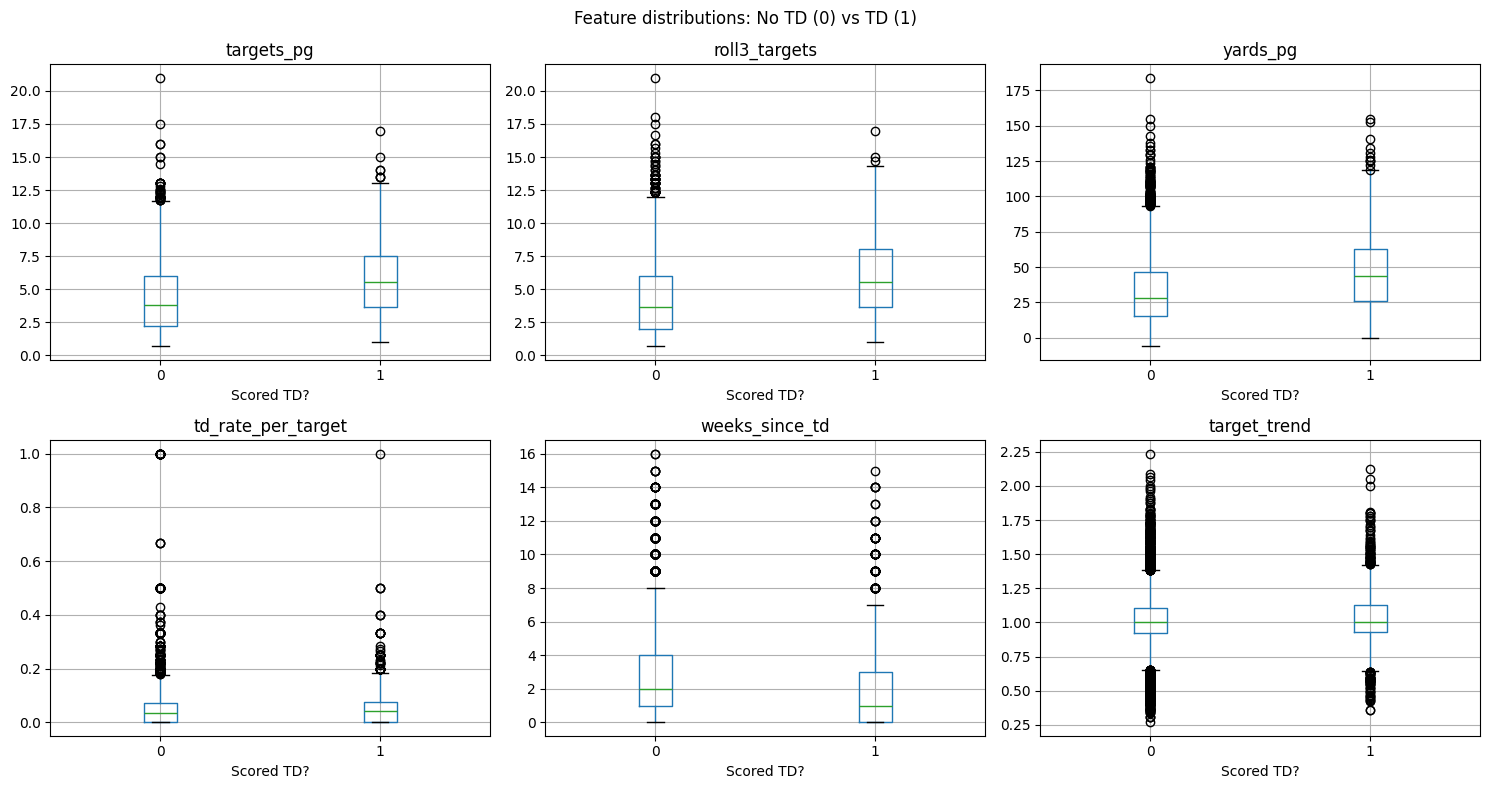

In [16]:
# Visualize top features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
top_feats = ['targets_pg', 'roll3_targets', 'yards_pg', 'td_rate_per_target', 'weeks_since_td', 'target_trend']

for ax, feat in zip(axes.flatten(), top_feats):
    in_season.boxplot(column=feat, by='scored_td', ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('Scored TD?')

plt.suptitle('Feature distributions: No TD (0) vs TD (1)')
plt.tight_layout()
plt.show()

In [17]:
# Early-season analysis (weeks 1-3): what prior-season features predict TDs?
# Build prior-season stats per player
prior_stats = df.groupby(['player_id', 'season']).agg(
    prior_games=('week', 'count'),
    prior_targets_pg=('targets', 'mean'),
    prior_yards_pg=('rec_yards', 'mean'),
    prior_receptions_pg=('receptions', 'mean'),
    prior_td_rate=('scored_td', 'mean'),
    prior_tds=('rec_tds', 'sum'),
).reset_index()
prior_stats['prior_td_per_target'] = (
    prior_stats['prior_tds'] / (prior_stats['prior_targets_pg'] * prior_stats['prior_games']).clip(lower=1)
)
prior_stats['next_season'] = prior_stats['season'] + 1

# Join to early-week rows
early = df_feat[df_feat['week'] <= 3].copy()
early = early.merge(
    prior_stats[['player_id', 'next_season', 'prior_games', 'prior_targets_pg',
                  'prior_yards_pg', 'prior_td_rate', 'prior_td_per_target']].rename(
        columns={'next_season': 'season'}),
    on=['player_id', 'season'],
    how='left'
)

print(f'Early-season rows with prior stats: {early["prior_targets_pg"].notna().sum()} / {len(early)}')
print()

early_with_prior = early[early['prior_targets_pg'].notna()]
prior_corr = early_with_prior[[
    'prior_targets_pg', 'prior_yards_pg', 'prior_td_rate', 'prior_td_per_target', 'scored_td'
]].corr()['scored_td'].drop('scored_td').sort_values(ascending=False)
print('Prior-season feature correlation with early-week TD:')
print(prior_corr.round(3))

Early-season rows with prior stats: 1158 / 1722

Prior-season feature correlation with early-week TD:
prior_yards_pg        0.177
prior_targets_pg      0.173
prior_td_rate         0.105
prior_td_per_target   0.002
Name: scored_td, dtype: float64


WR vs TE key stats comparison:
     targets  rec_yards  rec_tds  scored_td
pos                                        
TE     3.700     27.303    0.189      0.166
WR     5.046     40.590    0.250      0.218



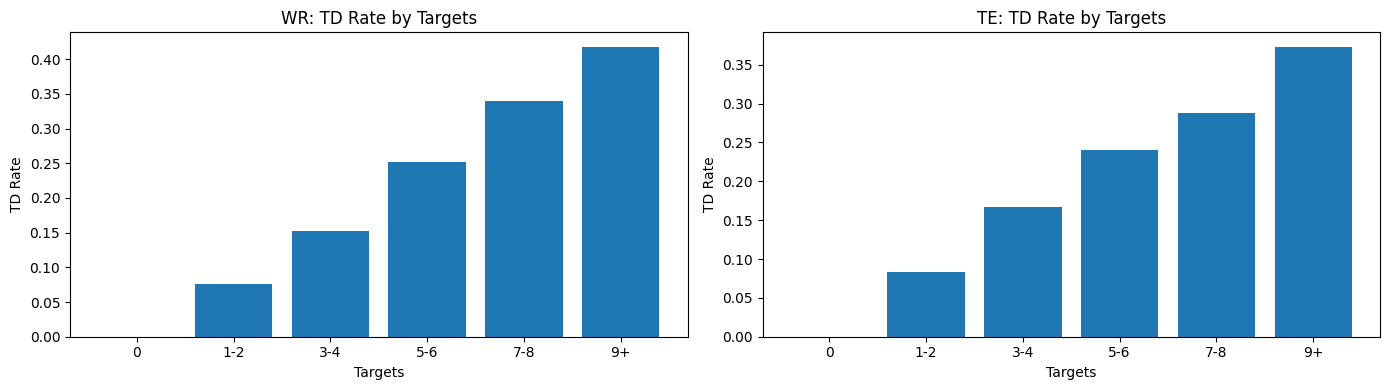

In [18]:
# WR vs TE comparison — do they need separate models?
print('WR vs TE key stats comparison:')
print(df.groupby('pos')[['targets', 'rec_yards', 'rec_tds', 'scored_td']].mean().round(3))
print()

# Look at TD rate by target volume separately for WR and TE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, pos in zip(axes, ['WR', 'TE']):
    sub = df[df['pos'] == pos].copy()
    sub['target_bucket'] = pd.cut(sub['targets'], bins=[-1, 0, 2, 4, 6, 8, 30],
                                   labels=['0', '1-2', '3-4', '5-6', '7-8', '9+'])
    td_rate = sub.groupby('target_bucket')['scored_td'].mean()
    ax.bar(td_rate.index.astype(str), td_rate.values)
    ax.set_title(f'{pos}: TD Rate by Targets')
    ax.set_xlabel('Targets')
    ax.set_ylabel('TD Rate')

plt.tight_layout()
plt.show()

In [19]:
# Year-over-year player consistency — how stable are usage signals?
yoy = prior_stats[prior_stats['prior_games'] >= 8].copy()
yoy_merged = yoy.merge(
    yoy[['player_id', 'season', 'prior_targets_pg', 'prior_yards_pg', 'prior_td_rate']].rename(
        columns={'season': 'next_season', 'prior_targets_pg': 'curr_targets_pg',
                 'prior_yards_pg': 'curr_yards_pg', 'prior_td_rate': 'curr_td_rate'}
    ),
    left_on=['player_id', 'next_season'],
    right_on=['player_id', 'next_season'],
    how='inner'
)

print(f'Year-over-year player pairs: {len(yoy_merged)}')
print()
print('Year-over-year feature stability (r = how consistent players are):')
print(yoy_merged[['prior_targets_pg', 'prior_yards_pg', 'prior_td_rate', 
                    'curr_targets_pg', 'curr_yards_pg', 'curr_td_rate']].corr().round(3))

Year-over-year player pairs: 373

Year-over-year feature stability (r = how consistent players are):
                  prior_targets_pg  prior_yards_pg  prior_td_rate  \
prior_targets_pg             1.000           0.934          0.609   
prior_yards_pg               0.934           1.000          0.684   
prior_td_rate                0.609           0.684          1.000   
curr_targets_pg              0.802           0.794          0.514   
curr_yards_pg                0.741           0.782          0.513   
curr_td_rate                 0.494           0.525          0.403   

                  curr_targets_pg  curr_yards_pg  curr_td_rate  
prior_targets_pg            0.802          0.741         0.494  
prior_yards_pg              0.794          0.782         0.525  
prior_td_rate               0.514          0.513         0.403  
curr_targets_pg             1.000          0.924         0.615  
curr_yards_pg               0.924          1.000         0.679  
curr_td_rate             

In [20]:
# Rookie analysis — how do first-year players perform vs veterans?
if 'exp' in df_feat.columns:
    rookies = df_feat[df_feat['exp'].astype(str) == 'R']
    vets = df_feat[~(df_feat['exp'].astype(str).isin(['R', '0', '1']))]
    print(f'Rookie game-weeks: {len(rookies)}')
    print(f'Vet game-weeks: {len(vets)}')
    print()
    print('Rookie vs vet TD rate:')
    print(f'  Rookies: {rookies["scored_td"].mean():.3f}')
    print(f'  Veterans: {vets["scored_td"].mean():.3f}')
else:
    print('Note: exp field not in dataset — add from player_lookup')
    df_feat['exp'] = df_feat['player_id'].map({pid: p['exp'] for pid, p in player_lookup.items()})
    print('Added exp from player_lookup')

Note: exp field not in dataset — add from player_lookup
Added exp from player_lookup


---
## Step 5 — Feature Set Decision

Based on the analysis above, document the final feature candidates.

In [21]:
# Quick sanity check: how many usable rows for training?
# In-season path: needs >= 1 prior game in season
train_data = df_feat[(df_feat['season'] <= 2024) & (df_feat['games_played'] >= 1)].copy()
holdout_data = df_feat[df_feat['season'] == 2025].copy()

print('TRAINING SET (2022-2024, in-season path):')
print(f'  Rows: {len(train_data)}')
print(f'  Players: {train_data["player_id"].nunique()}')
print(f'  TD rate: {train_data["scored_td"].mean():.3f}')
print(f'  WR: {(train_data["pos"]=="WR").sum()} rows | TE: {(train_data["pos"]=="TE").sum()} rows')
print()
print('HOLDOUT SET (2025):')
print(f'  Rows: {len(holdout_data)}')
print(f'  Players: {holdout_data["player_id"].nunique()}')
print(f'  TD rate: {holdout_data["scored_td"].mean():.3f}')

TRAINING SET (2022-2024, in-season path):
  Rows: 6297
  Players: 273
  TD rate: 0.206
  WR: 4090 rows | TE: 2207 rows

HOLDOUT SET (2025):
  Rows: 3026
  Players: 317
  TD rate: 0.197


In [22]:
# Proposed feature set for in-season model
IN_SEASON_FEATURES = [
    'week',
    'is_te',
    # Prior game
    'lag_yards',
    'lag_targets',
    # Season-to-date averages
    'yards_pg',
    'targets_pg',
    'receptions_pg',
    # Rolling 3-game
    'roll3_yards',
    'roll3_targets',
    # Efficiency
    'td_rate_per_target',
    'lag_ypr',
    # New signals
    'target_trend',
    'weeks_since_td',
]

EARLY_SEASON_FEATURES = [
    'week',
    'is_te',
    'prior_targets_pg',
    'prior_yards_pg',
    'prior_td_rate',
    'prior_td_per_target',
    # 'draft_round',  # to add once we have this mapped properly
]

print('IN-SEASON FEATURES:', len(IN_SEASON_FEATURES))
for f in IN_SEASON_FEATURES:
    avail = f in train_data.columns
    null_pct = train_data[f].isna().mean() if avail else None
    print(f'  {f}: {"OK" if avail else "MISSING"} | null%={null_pct:.1%}' if avail else f'  {f}: MISSING')

print()
print('EARLY-SEASON FEATURES:', len(EARLY_SEASON_FEATURES))

IN-SEASON FEATURES: 13
  week: OK | null%=0.0%
  is_te: OK | null%=0.0%
  lag_yards: OK | null%=0.0%
  lag_targets: OK | null%=0.0%
  yards_pg: OK | null%=0.0%
  targets_pg: OK | null%=0.0%
  receptions_pg: OK | null%=0.0%
  roll3_yards: OK | null%=0.0%
  roll3_targets: OK | null%=0.0%
  td_rate_per_target: OK | null%=0.0%
  lag_ypr: OK | null%=0.0%
  target_trend: OK | null%=0.0%
  weeks_since_td: OK | null%=0.0%

EARLY-SEASON FEATURES: 6


In [23]:
# Save the combined feature dataset for the next notebook (model training)
df_feat.to_csv(DATA_DIR / 'game_logs_features.csv', index=False)
print(f'Saved {len(df_feat)} rows to data/game_logs_features.csv')
print('Ready for 03_model_training.ipynb')

Saved 9972 rows to data/game_logs_features.csv
Ready for 03_model_training.ipynb
